In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [48]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

# X_train = 55,000 , X_valid = 5,000, X_test = 10,000
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

print(X_train.shape)
print(X_test.shape)

(55000, 28, 28)
(10000, 28, 28)


In [49]:
X_train.dtype

dtype('uint8')

In [50]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

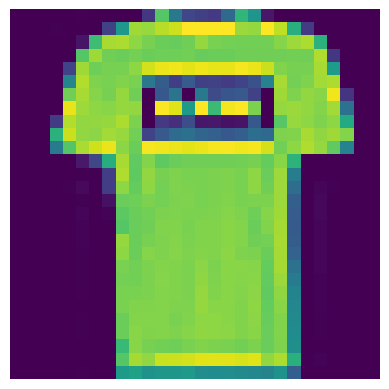

In [51]:
plt.imshow(X_train[1])
plt.axis("off")
plt.show()

In [52]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [54]:
class_names[y_train[1]]

'T-shirt/top'

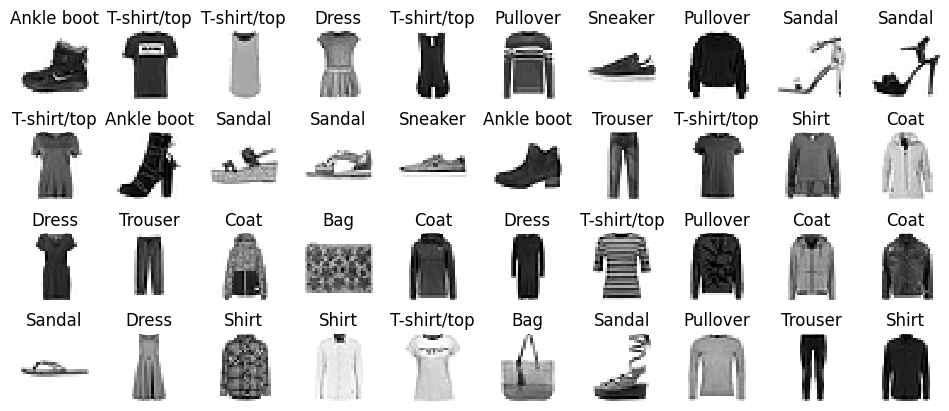

In [55]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

#### Creating the model using the Sequential API

In [56]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28,28]))

model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [57]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
!pip install pydot pydotplus graphviz

import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12


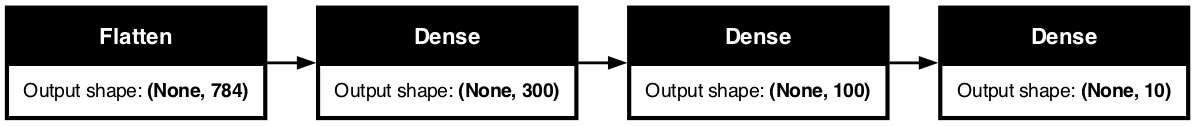

In [59]:
tf.keras.utils.plot_model(
    model,
    "my-model-sensoyyasin.png",
    show_shapes=True,
    dpi=100,
    rankdir="LR"
)

In [60]:
model.layers

[<Flatten name=flatten_3, built=True>,
 <Dense name=dense_9, built=True>,
 <Dense name=dense_10, built=True>,
 <Dense name=dense_11, built=True>]

In [61]:
hidden1 = model.layers[1]
hidden1.name

'dense_9'

In [62]:
weights, biases = hidden1.get_weights()
weights

array([[-0.0703951 , -0.02703425, -0.01933619, ..., -0.04962438,
        -0.03192159, -0.01269445],
       [ 0.00332746,  0.04602893,  0.03317223, ...,  0.06665087,
         0.02022711, -0.03089233],
       [ 0.00883576, -0.00057743, -0.06863304, ..., -0.05792791,
        -0.04582977,  0.04488246],
       ...,
       [-0.0688548 ,  0.03692444, -0.01852758, ...,  0.03377236,
        -0.04312744, -0.03035669],
       [ 0.0239226 ,  0.07229081,  0.0114582 , ..., -0.00349526,
        -0.00397841, -0.02943246],
       [ 0.06382459, -0.04289322, -0.02684442, ..., -0.05176124,
         0.00304976,  0.07352145]], dtype=float32)

In [63]:
weights.shape

(784, 300)

In [64]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [65]:
# Stochastic Gradient Descent

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0])

In [66]:
history = model.fit(X_train, y_train, epochs=50,
                   validation_data = (X_valid, y_valid))

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6813 - loss: 0.9968 - val_accuracy: 0.8292 - val_loss: 0.5024
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 990us/step - accuracy: 0.8251 - loss: 0.5074 - val_accuracy: 0.8440 - val_loss: 0.4514
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8430 - loss: 0.4527 - val_accuracy: 0.8474 - val_loss: 0.4281
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8539 - loss: 0.4219 - val_accuracy: 0.8496 - val_loss: 0.4119
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8603 - loss: 0.4003 - val_accuracy: 0.8544 - val_loss: 0.4001
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8662 - loss: 0.3832 - val_accuracy: 0.8562 - val_loss: 0.3888
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8707 - loss: 0.3687 - val_accuracy: 0.8584 - val_loss: 0.3821
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8752 - loss: 0.3567 

In [67]:
history.params

{'verbose': 'auto', 'epochs': 50, 'steps': 1719}

In [68]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


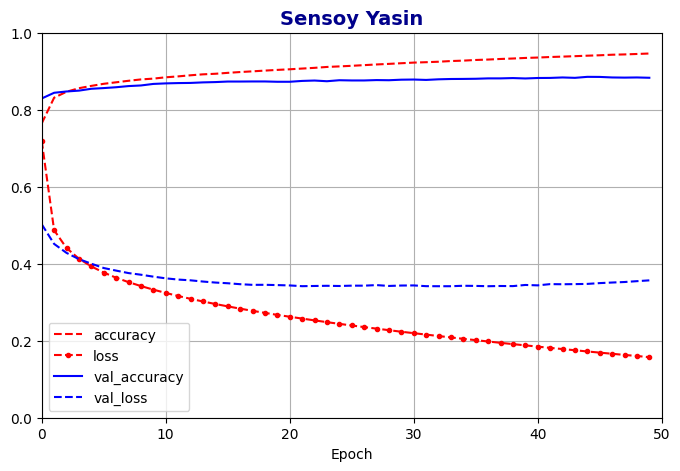

First Epoch:
Train Loss     : 0.7188
Val Loss       : 0.5024
Train Accuracy : 0.7645
Val Accuracy   : 0.8292

Last Epoch:
Train Loss     : 0.1572
Val Loss       : 0.3568
Train Accuracy : 0.9460
Val Accuracy   : 0.8830


In [69]:
pd.DataFrame(history.history).plot(
    figsize=(8,5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style = ["r--", "r--.","b-","b--"])

plt.legend(loc="lower left")
plt.title("Sensoy Yasin", fontsize=14, fontweight="bold", color="darkblue")
plt.show()

print("First Epoch:")
print(f"Train Loss     : {history.history['loss'][0]:.4f}")
print(f"Val Loss       : {history.history['val_loss'][0]:.4f}")
print(f"Train Accuracy : {history.history['accuracy'][0]:.4f}")
print(f"Val Accuracy   : {history.history['val_accuracy'][0]:.4f}")

print("\nLast Epoch:")
print(f"Train Loss     : {history.history['loss'][-1]:.4f}")
print(f"Val Loss       : {history.history['val_loss'][-1]:.4f}")
print(f"Train Accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Val Accuracy   : {history.history['val_accuracy'][-1]:.4f}")

In [70]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(test_loss)
print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - accuracy: 0.8822 - loss: 0.3707
0.3661653697490692
0.8822000026702881


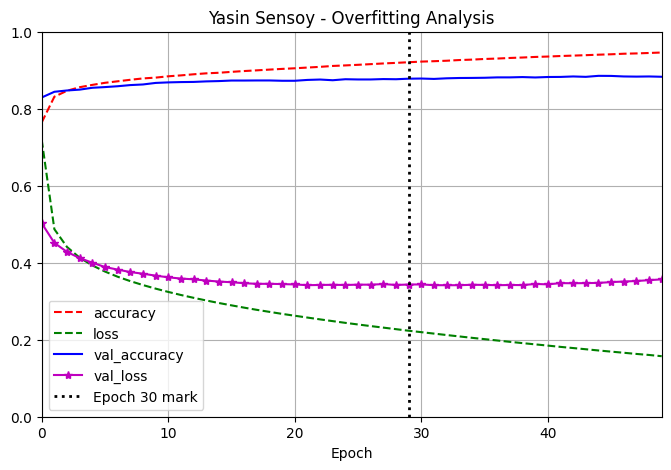

In [71]:
pd.DataFrame(history.history).plot(
    figsize=(8,5), xlim=[0, 49], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "g--", "b-", "m-*"])
plt.axvline(x=29, color='black', linestyle=':', linewidth=2, label='Epoch 30 mark')
plt.legend(loc="lower left")
plt.title("Yasin Sensoy - Overfitting Analysis")
plt.show()

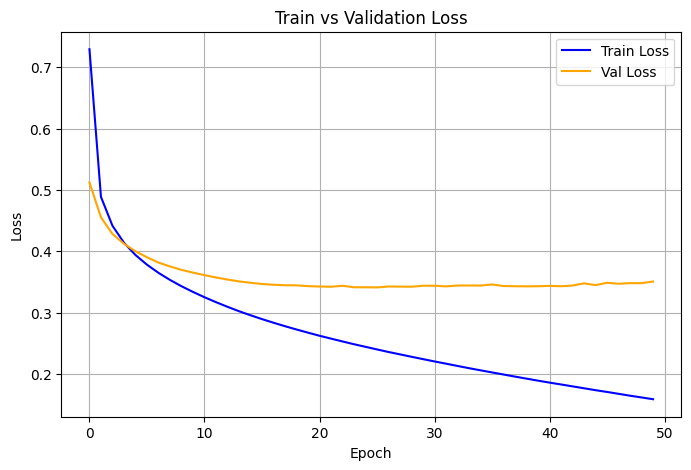

In [65]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()